# 📊 Social Media & Teen Mental Health: Exploratory Data Analysis

## 📌 Introducción

Las redes sociales se han convertido en una parte fundamental de la vida cotidiana de los adolescentes, influyendo en la forma en que se comunican, aprenden y se relacionan con su entorno. Sin embargo, el aumento en el tiempo de exposición a estas plataformas ha generado un creciente interés por comprender sus posibles efectos sobre el bienestar físico, emocional y mental de los jóvenes.

El objetivo de este proyecto es realizar un análisis exploratorio de datos (EDA) para investigar la relación entre el uso de redes sociales y diversos indicadores asociados a la salud mental de los adolescentes, tales como los niveles de estrés, ansiedad, adicción, calidad del sueño, actividad física e interacción social.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

In [4]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [5]:
df.shape

(1200, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 107.9+ KB


## 📌 Análisis

### 1. Most Used Social Media Platforms

In [7]:
print(df['platform_usage'].value_counts())

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


La distribución de usuarios entre Instagram, TikTok y el uso combinado de ambas plataformas es relativamente uniforme. Instagram es la plataforma más utilizada dentro de la muestra con 411 participantes, seguida por TikTok con 398 y el uso de ambas plataformas con 391 participantes. Esta distribución equilibrada permite realizar comparaciones entre grupos sin que exista una sobrerrepresentación significativa de alguna categoría.

### 2. Daily Social Media Usage

In [8]:
print(df['daily_social_media_hours'].describe())

count    1200.000000
mean        4.536667
std         2.029599
min         1.000000
25%         2.800000
50%         4.500000
75%         6.300000
max         8.000000
Name: daily_social_media_hours, dtype: float64


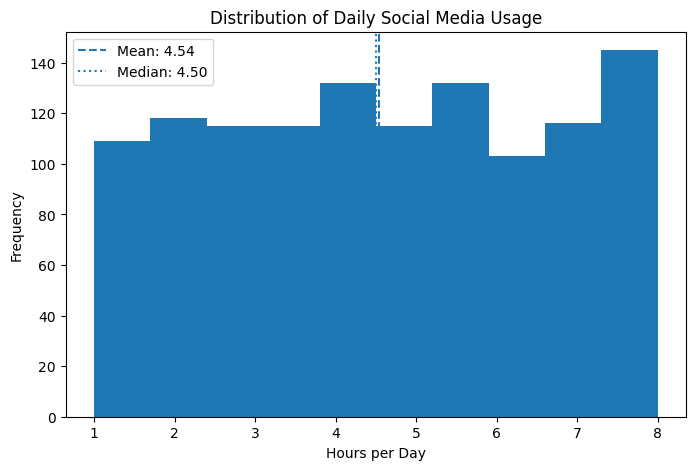

In [9]:
import matplotlib.pyplot as plt

mean_value = df['daily_social_media_hours'].mean()
median_value = df['daily_social_media_hours'].median()

plt.figure(figsize=(8,5))
plt.hist(df['daily_social_media_hours'], bins=10)

plt.axvline(mean_value, linestyle='--', label=f'Mean: {mean_value:.2f}')
plt.axvline(median_value, linestyle=':', label=f'Median: {median_value:.2f}')

plt.title('Distribution of Daily Social Media Usage')
plt.xlabel('Hours per Day')
plt.ylabel('Frequency')
plt.legend()

plt.show()

Los participantes utilizan redes sociales un promedio de 4.54 horas diarias. La mediana de 4.5 horas indica una distribución relativamente equilibrada, ya que ambos valores son muy similares. Además, el 50% de los usuarios dedica entre 2.8 y 6.3 horas al día a estas plataformas, con registros que oscilan entre 1 y 8 horas diarias, lo que evidencia un uso frecuente de las redes sociales dentro de la muestra analizada.

### 3. Social Media Usage vs Sleep Hours

In [10]:
correlation = df['daily_social_media_hours'].corr(df['sleep_hours'])
print(correlation)

-0.009472174451730861


El análisis de correlación entre las horas diarias de uso de redes sociales y las horas de sueño muestra un coeficiente de -0.009, lo que indica una relación prácticamente inexistente entre ambas variables. Además, el gráfico de dispersión no evidencia ningún patrón claro, sugiriendo que en esta muestra el tiempo dedicado a redes sociales no parece estar asociado con las horas de sueño de los participantes.

### 4. Social Media Usage and Mental Health

In [13]:
mental_health_cols = [
    'stress_level',
    'anxiety_level',
    'addiction_level',
    'depression_label'
]

df[mental_health_cols + ['daily_social_media_hours']].corr()['daily_social_media_hours'].sort_values(ascending=False)

daily_social_media_hours    1.000000
depression_label            0.175201
stress_level                0.030698
anxiety_level               0.027835
addiction_level            -0.024964
Name: daily_social_media_hours, dtype: float64

Los resultados muestran que la relación entre el tiempo diario de uso de redes sociales y los indicadores de salud mental es, en general, débil. La variable con mayor correlación fue la presencia de depresión (0.18), lo que sugiere una ligera tendencia a que mayores niveles de uso de redes sociales estén asociados con mayores niveles de depresión. Sin embargo, los niveles de estrés, ansiedad y adicción presentaron correlaciones cercanas a cero, indicando que en este conjunto de datos no existe una relación significativa entre estas variables y las horas de uso de redes sociales.

### 5. Social Media Usage and Physical Activity

In [15]:
df[['daily_social_media_hours', 'physical_activity']].corr()

,daily_social_media_hours,physical_activity
daily_social_media_hours,1.000000,0.025546
physical_activity,0.025546,1.000000


Los resultados muestran que no existe una relación significativa entre el tiempo diario dedicado a las redes sociales y el nivel de actividad física de los adolescentes. La correlación obtenida fue de 0.03, lo que indica una asociación prácticamente inexistente entre ambas variables en este conjunto de datos.

### 6. Social Media Usage and Academic Performance

In [16]:
df[['daily_social_media_hours', 'academic_performance']].corr()

,daily_social_media_hours,academic_performance
daily_social_media_hours,1.000000,0.013179
academic_performance,0.013179,1.000000


Los resultados muestran que no existe una relación significativa entre el tiempo diario dedicado a las redes sociales y el rendimiento académico de los adolescentes. La correlación obtenida fue de 0.01, un valor cercano a cero que indica una asociación prácticamente inexistente entre ambas variables dentro de este conjunto de datos.

### 7. Social Media Usage and Social Interaction Level

In [17]:
df['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

In [18]:
df.groupby('social_interaction_level')['daily_social_media_hours'].mean().sort_values()

social_interaction_level
high      4.457182
low       4.539518
medium    4.604327
Name: daily_social_media_hours, dtype: float64

El tiempo promedio de uso de redes sociales fue similar entre los distintos niveles de interacción social. Aunque los participantes con interacción social media presentaron un promedio ligeramente superior, las diferencias entre grupos fueron mínimas, lo que sugiere que no existe una relación relevante entre ambas variables en este conjunto de datos.

### 8. Gender Differences in Social Media Usage

In [19]:
df.groupby('gender')['daily_social_media_hours'].agg(['count','mean'])

,count,mean
gender,,
female,585,4.512991
male,615,4.559187


Los resultados muestran que el tiempo promedio de uso diario de redes sociales es muy similar entre hombres y mujeres. Los participantes masculinos registraron un promedio de 4.56 horas diarias, mientras que las participantes femeninas presentaron un promedio de 4.51 horas. La diferencia observada es mínima, lo que sugiere que el género no parece influir significativamente en el tiempo dedicado a las redes sociales dentro de este conjunto de datos.

## 📌 Conclusiones

El presente análisis exploró la relación entre el uso de redes sociales y diferentes factores asociados al bienestar de los adolescentes, como el sueño, la salud mental, la actividad física, el rendimiento académico, la interacción social y el género. Los resultados mostraron que la mayoría de las variables presentaron correlaciones débiles o prácticamente inexistentes con las horas diarias de uso de redes sociales. La única asociación destacable fue una relación positiva débil con la variable de depresión. Asimismo, no se observaron diferencias relevantes en el uso de redes sociales según el nivel de interacción social o el género. En general, los hallazgos sugieren que, dentro de este conjunto de datos, el tiempo dedicado a las redes sociales no constituye un factor determinante para explicar las diferencias observadas en los indicadores analizados.